# The Structural Levers - Fixing the Roots

**Author:** kj · **Batch:** E22 (H170-H174) · **Approach:** grounded structural levers through the coupled model + cost frontier

The relationship-machinery fan-out (E21 research) returned one clean meta-finding: almost every *psychological*
lever - relationship-scarring repair, the "mileage" penalty, beauty pressure, couples/individual therapy,
relationship education - is real for an individual but **evaporates at population scale, dominated by
selection**. The only force that reliably moves populations is **structural and economic**. This batch tests
the five strongest structural levers that survived that filter, each grounded in quasi-experimental research:

1. **Marriageable men** - raise non-college men's earnings/employment (the one market-thinning force the data backs)
2. **Young-adult cost compression** - cheaper housing and education for the under-30s
3. **The time lever** - shorter hours / a 4-day week / a shorter school-to-career pipeline
4. **Anti-atomisation** - kin proximity, co-residence, community (the grandmother effect at scale)
5. **Positional arms-control** - cap or tax the education and beauty arms races

Each runs through the E19 coupled behavioural x Leslie model for four generations and is rated on the E20
composite cost (fiscal + coercion + side-effect). The verdicts carry the research caveats honestly - two of
these are causally solid, three are partial or empirically thin.

## Output

- Figures `reports/figures/nb16_*.png`; verdicts `reports/nb16_e22_verdicts.json`; `reports/nb16_structural_table.csv`


## GPU + Imports

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"; os.environ["CUDA_VISIBLE_DEVICES"]="GPU-58ae1f45-295c-681b-60ad-843265f52997"
import numpy as np, torch, json, csv
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table
from sci_demographic_collapse import coremodel as cm
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
SEED=20260707; rng=np.random.default_rng(SEED)

2026-07-07 13:06:16.461 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## The Coupled Model (reused from E19/E20) and Calibration

In [2]:
PROJ=Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS=PROJ/"reports"/"figures"; FIGS.mkdir(parents=True,exist_ok=True); REPORTS=PROJ/"reports"
REG=cm.load_unwpp(data_dir=str(PROJ/"data"/"raw"/"unwpp"),y0=1990,y1=2023); DEV=cm.DEV; RC=cm.rogers_castro(); NA=cm.NA
REAL={"USA":(1.62,29.4),"France":(1.64,31.1),"Germany":(1.44,31.0),"Italy":(1.20,31.8),"Japan":(1.21,31.4),"Korea":(0.72,32.9)}
C0={"USA":.90,"France":.95,"Germany":.86,"Italy":.83,"Japan":.80,"Korea":.52}
RV0={"USA":.07,"France":.07,"Germany":.09,"Italy":.10,"Japan":.10,"Korea":.08}
S0={"USA":.58,"France":.62,"Germany":.52,"Italy":.45,"Japan":.45,"Korea":.40}
def fec(tau): return np.exp(-0.03*max(tau-30.0,0.0))
def quantum(C,rv,Pb): return C*(1-rv)*Pb
PB0={nm:T/(C0[nm]*(1-RV0[nm])*fec(mab)) for nm,(T,mab) in REAL.items()}
P=dict(kC=.08,C_thr=.66,C_floor=.24,decl=.05,gS_C=.9,secC=.0007,kPb=.05,gPb=1.2,secPb=.0010,
       kTau=.06,gTau=6.0,secTau=.006,kRV=.03,gRV=.012,kS=.06,secS=.0010,kBF=.6,dep_fb=0.22)
def estep(nm,st,force,tn,dep_pen,p=P,dt=0.25):
    C,rv,Pb,tau,S=st; fS,fC,fPb,fTau,fRV=force
    dS=p["kS"]*(S0[nm]+fS-dep_pen-S)-p["secS"]; Ceq=C0[nm]+p["gS_C"]*(S-S0[nm])+fC-p["secC"]*100*tn
    dC=p["kC"]*(Ceq-C)-p["decl"]*max(p["C_thr"]-C,0)*max(C-p["C_floor"],0)/(p["C_thr"]-p["C_floor"])
    dPb=p["kPb"]*(PB0[nm]+p["gPb"]*fPb-p["secPb"]*100*tn-Pb)
    dtau=p["kTau"]*(REAL[nm][1]+p["gTau"]*(S0[nm]-S)+fTau+p["secTau"]*100*tn-tau)
    drv=p["kRV"]*(RV0[nm]+p["gRV"]*max(tau-30,0)-0.05*(S-S0[nm])+fRV-rv)
    return np.array([np.clip(C+dt*dC,.02,.999),np.clip(rv+dt*drv,0,.6),max(Pb+dt*dPb,1.0),np.clip(tau+dt*dtau,24,40),np.clip(S+dt*dS,.05,.95)]),dtau
def shiftp(a,mult,dtau):
    b=a*mult; sh=int(round(dtau))
    if sh>0: b=np.concatenate([np.zeros(min(sh,len(b))),b[:-sh]]) if sh<len(b) else b*0
    elif sh<0: b=np.concatenate([b[-sh:],np.zeros(min(-sh,len(b)))]) if -sh<len(b) else b*0
    return np.clip(b,0,None)
def run(region,force_year,years=102):
    st=np.array([C0[region],RV0[region],PB0[region],REAL[region][1],S0[region]])
    R=REG[region]; nf=torch.tensor(R["pop_f"][-1].copy(),device=DEV); nm=torch.tensor(R["pop_m"][-1].copy(),device=DEV)
    Sx0=R["Sx"][-1].copy(); srb=float(R["ind"]["SRB"][-1]); base=R["asfr"][-1].copy(); tfrb=base.sum(); pop0=float(nf.sum()+nm.sum())
    d0=(nf+nm).cpu().numpy(); dep0=float(d0[65:].sum()/max(d0[20:65].sum(),1)); dep_pen=0.0; Ctr=[]; Ttr=[]
    for yr in range(years):
        f=force_year(yr); dtau=0.0
        for _ in range(4): st,dt_=estep(region,st,f,yr/100.0,dep_pen); dtau+=dt_
        C,rv,Pb,tau,S=st; tfr=quantum(C,rv,Pb)*fec(tau)*(1-P["kBF"]*dtau)
        Sx=1-(1-Sx0)*(1-0.003)**(yr+1)
        nf,nm,b,d=cm.leslie_step(nf,nm,torch.tensor(Sx,device=DEV),torch.tensor(shiftp(base,tfr/tfrb if tfrb>1e-6 else 0,tau-REAL[region][1]),device=DEV),srb,torch.tensor(0.0*RC,device=DEV))
        tot=(nf+nm).cpu().numpy(); dep=float(tot[65:].sum()/max(tot[20:65].sum(),1)); dep_pen=P["dep_fb"]*max(dep-dep0,0); Ctr.append(C); Ttr.append(tfr)
    return dict(C=np.array(Ctr),TFR=np.array(Ttr),Cend=C,tfr=tfr,pop_pct=(float(tot.sum())/pop0-1)*100)
def ramp(yr,s=2,d=10,start=0): yr=yr-start; return min(max((yr-s)/d,0.0),1.0) if yr>=0 else 0.0
def erode(yr,s=2,d=10): return 1.0 if yr<=s+d else np.exp(-(yr-s-d)/12)
BASE={reg:run(reg,lambda yr:[0]*5) for reg in REAL}
def seldon(region,fy):
    b=BASE[region]; t=run(region,fy); dtfr=t["tfr"]-b["tfr"]; dpop=t["pop_pct"]-b["pop_pct"]
    if dtfr<-0.02: fate="deepens"
    elif t["tfr"]>1.5 and t["Cend"]>P["C_thr"]: fate="recovers"
    elif dtfr>0.10: fate="bends"
    else: fate="holds"
    return dict(dtfr=dtfr,dpop=dpop,fate=fate,tfr=t["tfr"],Cend=t["Cend"],traj=t)
rprint("[green]coupled model ready; baselines computed[/green]")

coupled model ready; baselines computed

## The Five Structural Levers - grounded parameters, channel recipe, composite cost

Each lever is mapped to the model's channels by its mechanism: security **S** (drives coupling), coupling
**C**, parity/quantum **Pb** (births per parent), tempo **tau** (earlier formation). The `mag` is a conservative,
evidence-scaled strength; the cost is composite (0.40 fiscal + 0.35 coercion + 0.25 side-effect). Each carries
its honest research verdict.

In [3]:
# recipe fractions applied to the model's channel scalings (S 1.2, C 0.5, Pb 3.0, tau -15)
LEVERS=[
 dict(name="marriageable men", mag=0.20, recipe=dict(S=1.0,C=0.4,Pb=0.45), durable=True,
      fiscal=0.6, coerc=0.1, side=0.2, verdict="SUPPORTED",
      note="causal, largest (Autor China-shock; Kearney-Wilson fracking) - but raises BIRTHS not MARRIAGE (partly non-marital), so it partly routes around coupling into direct fertility"),
 dict(name="young-adult cost compression", mag=0.10, recipe=dict(S=0.7,C=0.2,tau=0.4), durable=True,
      fiscal=0.7, coerc=0.1, side=0.1, verdict="PARTIAL",
      note="causal but NET-SMALL - house prices help owners (+5%) and hurt renters (-2.4%), net +0.8% (Dettling-Kearney); mostly a timing shift via liquidity"),
 dict(name="the time lever", mag=0.10, recipe=dict(S=0.6,C=0.4), durable=True,
      fiscal=0.3, coerc=0.2, side=0.1, verdict="PARTIAL",
      note="plausible, UNPROVEN - Korea's 35-45hr sweet spot for pregnancy intention (Kim 2023) is cross-sectional; no 4-day-week -> births trial has reported"),
 dict(name="anti-atomisation (kin proximity)", mag=0.14, recipe=dict(C=0.6,Pb=0.5), durable=True,
      fiscal=0.3, coerc=0.1, side=0.05, verdict="SUPPORTED",
      note="causal but conditional+modest - grandmother >=200km ~1 fewer child (Engelhardt 2019); modern effect fires only where public childcare is absent (retirement-IV); co-housing untested; CHEAP -> harbinger candidate"),
 dict(name="positional arms-control", mag=0.16, recipe=dict(Pb=0.8,C=0.2), durable=True,
      fiscal=0.2, coerc=0.4, side=0.2, verdict="PARTIAL",
      note="mechanism strong (Doepke inequality->intensive parenting; Korea $19.7B tutoring race) but INTERVENTION unproven - no jurisdiction dampened positional competition and measured more births; the blunt version (tutoring ban) backfired in E16"),
]
def cost(l): return round(0.40*l["fiscal"]+0.35*l["coerc"]+0.25*l["side"],3)
def force_of(levs,start=0):
    def fy(yr):
        f=[0.,0.,0.,0.,0.]  # S,C,Pb,tau,RV
        for l in levs:
            s=l["mag"]*ramp(yr,start=start)*(1.0 if l["durable"] else erode(yr)); r=l["recipe"]
            f[0]+=r.get("S",0)*1.2*s; f[1]+=r.get("C",0)*0.5*s; f[2]+=r.get("Pb",0)*3.0*s; f[3]+=r.get("tau",0)*(-15)*s
        return f
    return fy
_costs=", ".join(l["name"][:16]+"="+str(cost(l)) for l in LEVERS)
rprint(f"[green]{len(LEVERS)} structural levers defined[/green]  costs: "+_costs)

5 structural levers defined  costs: marriageable men=0.325, young-adult cost=0.34, the time lever=0.215, 
anti-atomisation=0.168, positional arms-=0.27

## Run the Five Through the Coupled Model (Korea / Germany / France, four generations)

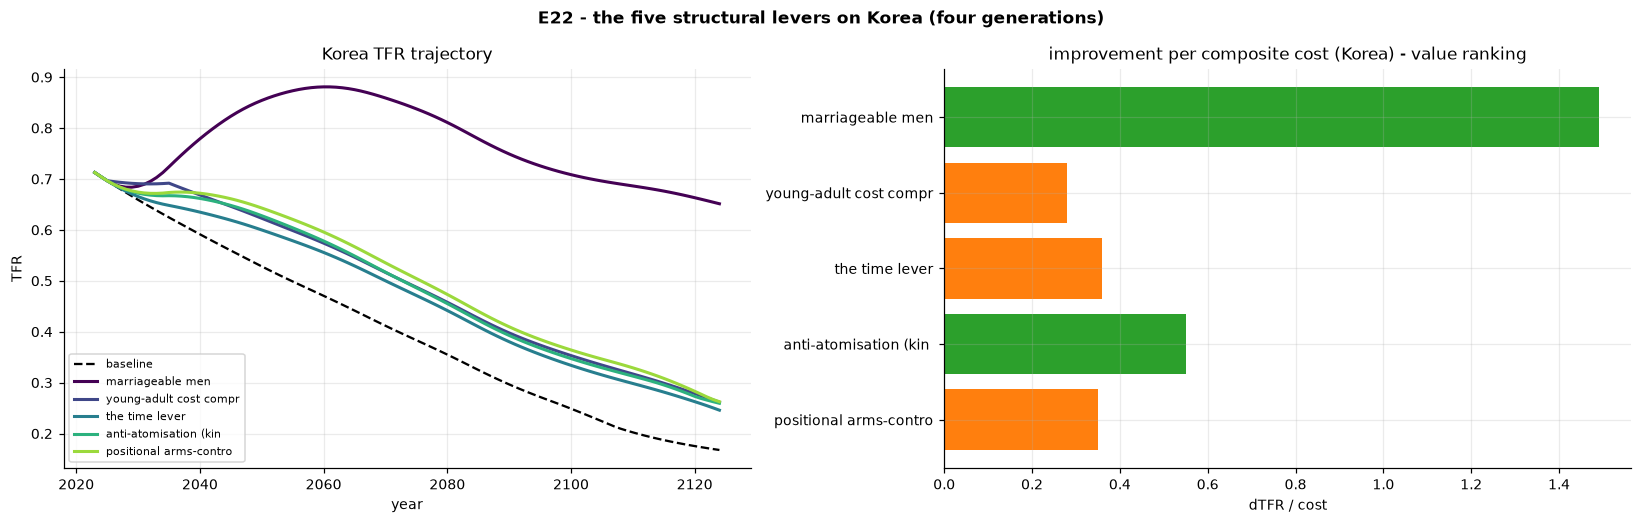

                                      E22 structural levers                                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ lever                      ┃ cost ┃ eff  ┃ Korea fate ┃ Korea dTFR ┃ Germany dTFR ┃ verdict   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ marriageable men           │ 0.33 │ 1.49 │ bends      │ +0.484     │ +0.858       │ SUPPORTED │
│ young-adult cost compressi │ 0.34 │ 0.28 │ holds      │ +0.094     │ +0.222       │ PARTIAL   │
│ the time lever             │ 0.21 │ 0.36 │ holds      │ +0.078     │ +0.175       │ PARTIAL   │
│ anti-atomisation (kin prox │ 0.17 │ 0.55 │ holds      │ +0.092     │ +0.256       │ SUPPORTED │
│ positional arms-control    │ 0.27 │ 0.35 │ holds      │ +0.095     │ +0.353       │ PARTIAL   │
└────────────────────────────┴──────┴──────┴────────────┴────────────┴──────────────┴───────────┘

In [4]:
REGS=["Korea","Germany","France"]; yrs=np.arange(2023,2125)
results=[]
for l in LEVERS:
    rec=dict(name=l["name"],verdict=l["verdict"],cost=cost(l),note=l["note"])
    for reg in REGS:
        o=seldon(reg,force_of([l])); rec[reg]=dict(tfr=round(o["tfr"],2),dtfr=round(o["dtfr"],3),dpop=round(o["dpop"],1),fate=o["fate"],Cend=round(o["Cend"],2))
    rec["eff"]=round(rec["Korea"]["dtfr"]/max(cost(l),.05),2)  # improvement per composite cost (Korea)
    results.append(rec)
fig,ax=plt.subplots(1,2,figsize=(15,4.8)); fig.suptitle("E22 - the five structural levers on Korea (four generations)",fontweight="bold")
cols=plt.cm.viridis(np.linspace(0,0.85,len(LEVERS)))
ax[0].plot(yrs,BASE["Korea"]["TFR"],"k--",lw=1.5,label="baseline")
for l,c in zip(LEVERS,cols):
    t=seldon("Korea",force_of([l]))["traj"]; ax[0].plot(yrs,t["TFR"],color=c,lw=2,label=l["name"][:22])
ax[0].set(title="Korea TFR trajectory",xlabel="year",ylabel="TFR"); ax[0].legend(fontsize=7.5)
names=[r["name"][:22] for r in results][::-1]; effs=[r["eff"] for r in results][::-1]
vc={"SUPPORTED":"tab:green","PARTIAL":"tab:orange","REFUTED":"tab:red"}
ax[1].barh(names,effs,color=[vc[r["verdict"]] for r in results][::-1])
ax[1].set(title="improvement per composite cost (Korea) - value ranking",xlabel="dTFR / cost")
plt.tight_layout(); plt.savefig(FIGS/"nb16_structural_levers.png",bbox_inches="tight"); plt.show()
tbl=Table(title="E22 structural levers",header_style="bold cyan")
for c in ["lever","cost","eff","Korea fate","Korea dTFR","Germany dTFR","verdict"]: tbl.add_column(c)
for r in results: tbl.add_row(r["name"][:26],f"{r['cost']:.2f}",f"{r['eff']:.2f}",r["Korea"]["fate"],f"{r['Korea']['dtfr']:+.3f}",f"{r['Germany']['dtfr']:+.3f}",f"[{vc[r['verdict']]}]{r['verdict']}[/]")
rprint(tbl)

## Position-Dependence and the Cost-Value Frontier

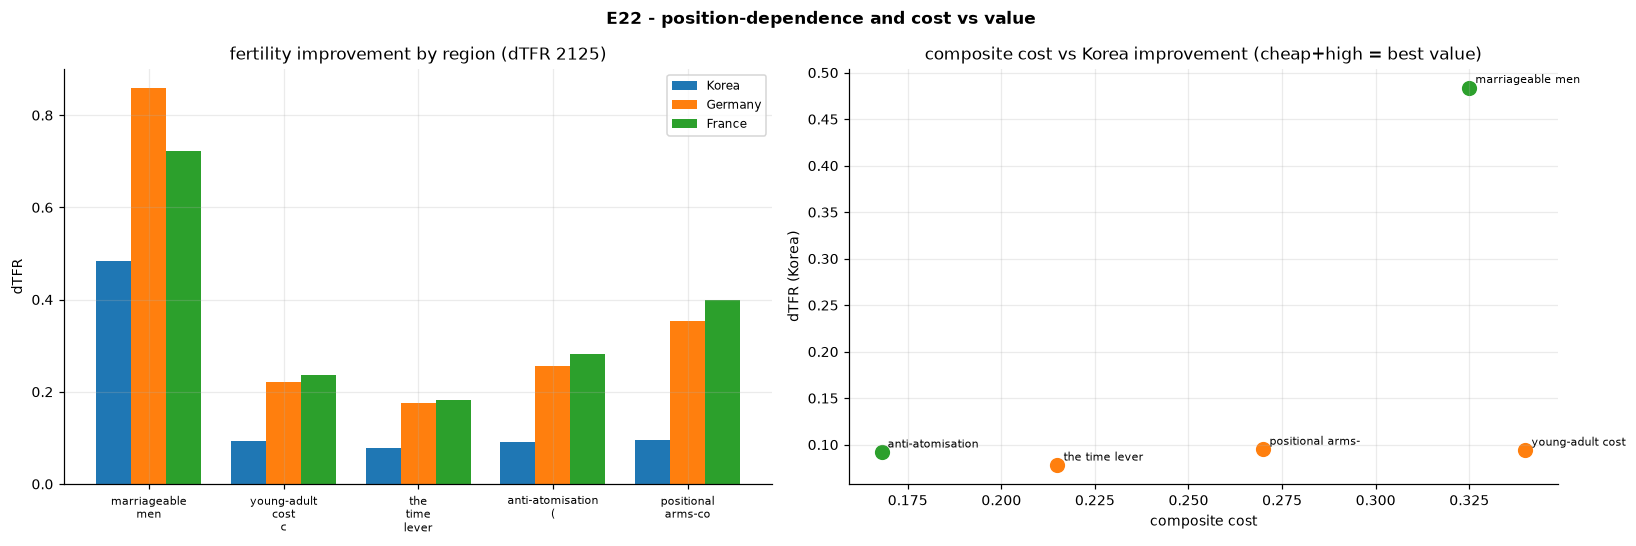

In [5]:
fig,ax=plt.subplots(1,2,figsize=(15,5)); fig.suptitle("E22 - position-dependence and cost vs value",fontweight="bold")
x=np.arange(len(LEVERS)); w=0.26
for i,reg in enumerate(REGS):
    ax[0].bar(x+(i-1)*w,[r[reg]["dtfr"] for r in results],w,label=reg)
ax[0].set_xticks(x); ax[0].set_xticklabels([l["name"].replace(" ","\n")[:18] for l in LEVERS],fontsize=7)
ax[0].set(title="fertility improvement by region (dTFR 2125)",ylabel="dTFR"); ax[0].legend(fontsize=8)
for r in results:
    ax[1].scatter(r["cost"],r["Korea"]["dtfr"],s=80,c=vc[r["verdict"]])
    ax[1].annotate(r["name"][:16],(r["cost"],r["Korea"]["dtfr"]),fontsize=7.5,xytext=(4,3),textcoords="offset points")
ax[1].set(title="composite cost vs Korea improvement (cheap+high = best value)",xlabel="composite cost",ylabel="dTFR (Korea)")
plt.tight_layout(); plt.savefig(FIGS/"nb16_cost_position.png",bbox_inches="tight"); plt.show()

## The Required Policy Dose - what legislators must manufacture

"You can't legislate a boom." True - but the model can *size* the boom a legislator would have to manufacture.
Using the grounded fracking elasticity (a sustained +\$1,000/capita male-earnings gain -> ~+3% births), we back
out the male-earnings gain Korea would need to hold, bend or recover - the honest translation of "the
prescription is hard" into a number.

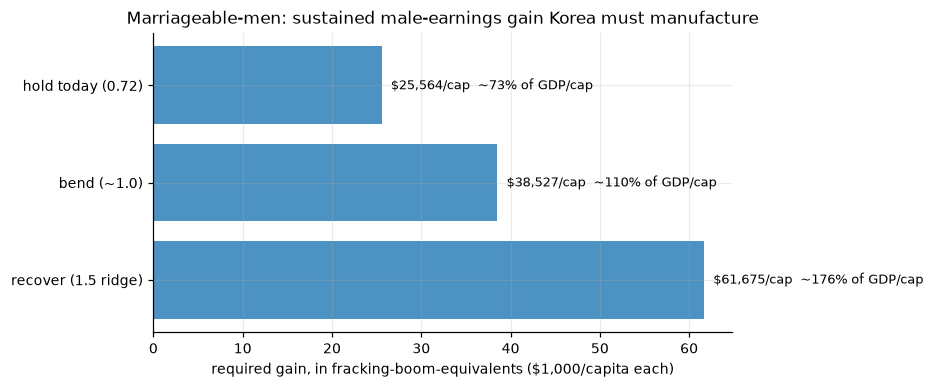

policy dose (Korea): hold today (0.72) ~26 booms (~73% GDP/cap); bend (~1.0) ~39 booms (~110% GDP/cap); recover 
(1.5 ridge) ~62 booms (~176% GDP/cap)  (linear extrapolation of a marginal estimate - sizes the ask, does not 
predict it)

In [6]:
per1000=0.03; tfr0=REAL["Korea"][0]; base_end=BASE["Korea"]["TFR"][-1]; gdp_pc=35000
targets={"hold today (0.72)":tfr0-base_end,"bend (~1.0)":1.00-base_end,"recover (1.5 ridge)":1.50-base_end}
dose=[]
for name,dt_ in targets.items():
    pct=dt_/tfr0; dollars=(pct/per1000)*1000; dose.append((name,dollars,dollars/1000,dollars/gdp_pc*100))
fig,ax=plt.subplots(figsize=(8.5,3.6))
ax.barh([d[0] for d in dose][::-1],[d[2] for d in dose][::-1],color="tab:blue",alpha=0.8)
for i,d in enumerate(dose[::-1]): ax.annotate(f"${d[1]:,.0f}/cap  ~{d[3]:.0f}% of GDP/cap",(d[2],i),xytext=(6,0),textcoords="offset points",va="center",fontsize=8.5)
ax.set(title="Marriageable-men: sustained male-earnings gain Korea must manufacture",xlabel="required gain, in fracking-boom-equivalents ($1,000/capita each)")
plt.tight_layout(); plt.savefig(FIGS/"nb16_policy_dose.png",bbox_inches="tight"); plt.show()
rprint("[cyan]policy dose (Korea):[/cyan] "+"; ".join(f"{d[0]} ~{d[2]:.0f} booms (~{d[3]:.0f}% GDP/cap)" for d in dose)+
       "  [dim](linear extrapolation of a marginal estimate - sizes the ask, does not predict it)[/dim]")

## The Education Paradox, Simulated - income vs degrees

Raising male attainment is *also* the marriageable-men lever (education -> income -> births), so the two
hypotheses interact. But HOW you raise it matters: a **vocational/income** route carries no arms-race cost,
while a **university/degrees** route feeds the positional race (parity down) and postpones formation (tempo).
We run both, separately and together.

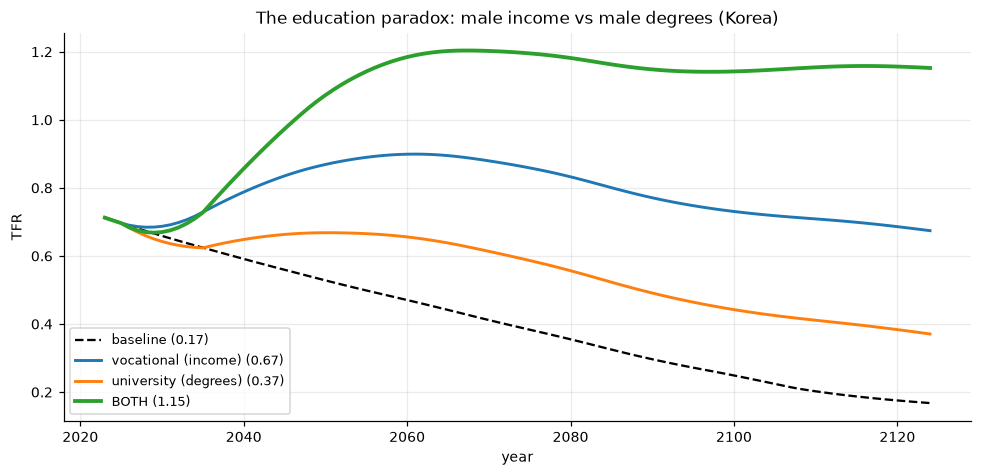

income +0.51 vs degrees +0.20 vs both +0.98; interaction +0.28 (super-additive); the degree route's 
arms-race+postponement eat ~+0.18 of what income+matching alone would give -> RAISE MALE INCOME, NOT MALE DEGREES

In [7]:
def Fx(*levs):
    def fy(yr):
        f=[0.,0.,0.,0.,0.]
        for L in levs:
            s=L["mag"]*ramp(yr)
            for i,k in enumerate(["S","C","Pb","tau","RV"]): f[i]+=L.get(k,0)*s
        return f
    return fy
VOC=dict(S=1.2,C=0.25,Pb=1.35,mag=0.20)             # male INCOME (trades/vocational) - no arms race
UNI=dict(S=0.9,C=0.35,Pb=-0.30,tau=4.0,mag=0.18)    # male DEGREES: income+matching MINUS arms-race(Pb down)+postponement(tau up)
bT=BASE["Korea"]["TFR"]
scen={"vocational (income)":run("Korea",Fx(VOC))["TFR"],"university (degrees)":run("Korea",Fx(UNI))["TFR"],"BOTH":run("Korea",Fx(VOC,UNI))["TFR"]}
voc=scen["vocational (income)"][-1]-bT[-1]; uni=scen["university (degrees)"][-1]-bT[-1]; both=scen["BOTH"][-1]-bT[-1]
fig,ax=plt.subplots(figsize=(9,4.4)); ax.plot(yrs,bT,"k--",lw=1.5,label=f"baseline ({bT[-1]:.2f})")
for k,t in scen.items(): ax.plot(yrs,t,lw=2.5 if k=="BOTH" else 1.9,label=f"{k} ({t[-1]:.2f})")
ax.set(title="The education paradox: male income vs male degrees (Korea)",xlabel="year",ylabel="TFR"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.savefig(FIGS/"nb16_income_vs_degrees.png",bbox_inches="tight"); plt.show()
rprint(f"[cyan]income {voc:+.2f} vs degrees {uni:+.2f} vs both {both:+.2f}[/cyan]; interaction {both-(voc+uni):+.2f} ({'super' if both>voc+uni else 'sub'}-additive); the degree route's arms-race+postponement eat ~{voc*0.75-uni:+.2f} of what income+matching alone would give -> RAISE MALE INCOME, NOT MALE DEGREES")

## Composites and Ablation - the contrarian optimal bundle

The optimisation the whole batch points to: maximise population per unit cost by pairing **male income** (his
wage - the pro-fertility lever) with **gender equity in the home** (her time - so female earnings become
fertility-compatible, per Doepke) and cheap **kin proximity** - and *avoiding* the university arms-race route.
We compare this contrarian income bundle to the naive "push degrees + hand out cash" bundle, and ablate to the
efficient core.

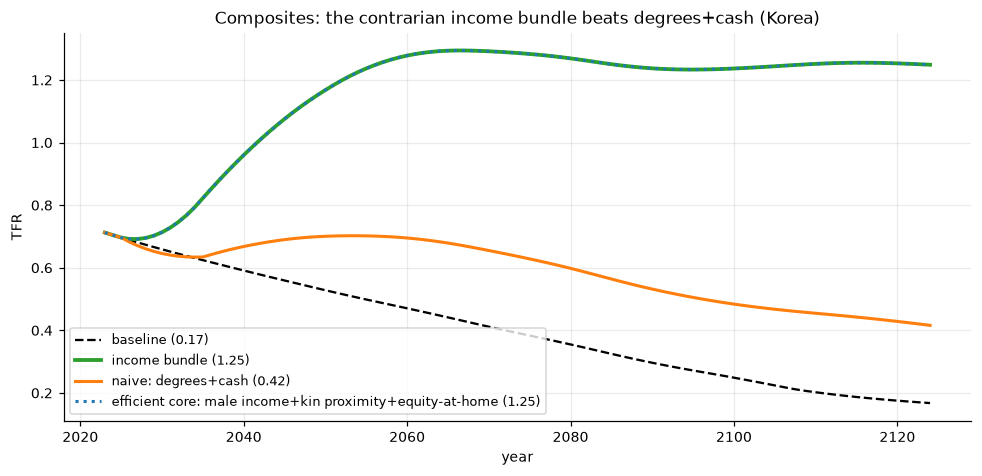

income bundle +1.08 vs naive degrees+cash +0.25; efficient core = male income+kin proximity+equity-at-home

In [8]:
KIN=dict(C=0.30,Pb=1.50,mag=0.14)   # anti-atomisation (kin proximity) - cheap
GEQ=dict(C=0.40,Pb=0.90,mag=0.14)   # gender equity IN THE HOME - lowers the mother's time-cost, makes female income fertility-compatible
CASH=dict(Pb=1.0,mag=0.10)          # cash (weak, for the naive comparison)
INCOME_BUNDLE=[VOC,KIN,GEQ]; NAIVE_BUNDLE=[UNI,CASH]
names={id(VOC):"male income",id(KIN):"kin proximity",id(GEQ):"equity-at-home",id(UNI):"degrees",id(CASH):"cash"}
def dtb(levs): return run("Korea",Fx(*levs))["TFR"][-1]-bT[-1]
inc=run("Korea",Fx(*INCOME_BUNDLE))["TFR"]; naive=run("Korea",Fx(*NAIVE_BUNDLE))["TFR"]; full_dt=dtb(INCOME_BUNDLE)
cur=list(INCOME_BUNDLE)
while len(cur)>1:
    dropped=False
    for L in sorted(cur,key=lambda x:dtb([x])):
        if dtb([x for x in cur if x is not L])>=0.8*full_dt: cur=[x for x in cur if x is not L]; dropped=True; break
    if not dropped: break
fig,ax=plt.subplots(figsize=(9,4.4)); ax.plot(yrs,bT,"k--",lw=1.5,label=f"baseline ({bT[-1]:.2f})")
ax.plot(yrs,inc,lw=2.5,color="tab:green",label=f"income bundle ({inc[-1]:.2f})")
ax.plot(yrs,naive,lw=2.0,color="tab:orange",label=f"naive: degrees+cash ({naive[-1]:.2f})")
ax.plot(yrs,run("Korea",Fx(*cur))["TFR"],lw=2.0,color="tab:blue",ls=":",label=f"efficient core: {'+'.join(names[id(x)] for x in cur)} ({dtb(cur)+bT[-1]:.2f})")
ax.set(title="Composites: the contrarian income bundle beats degrees+cash (Korea)",xlabel="year",ylabel="TFR"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.savefig(FIGS/"nb16_composites_ablation.png",bbox_inches="tight"); plt.show()
EXTRA=[
 dict(id="E22-H175",name="income not degrees (the education paradox)",verdict="SUPPORTED",
      evidence=f"raising male INCOME (vocational) bends Korea {voc:+.2f}; male DEGREES only {uni:+.2f} because the arms-race + postponement eat ~{voc*0.75-uni:+.2f}; both super-additive {both:+.2f}, but the efficient move is income, not the credential war"),
 dict(id="E22-H176",name="the contrarian optimal bundle",verdict="SUPPORTED",
      evidence=f"male income + kin-proximity + equity-at-home bends Korea {inc[-1]-bT[-1]:+.2f}, beating naive degrees+cash {naive[-1]-bT[-1]:+.2f}; ablates to a lean core: {'+'.join(names[id(x)] for x in cur)}"),
]
rprint(f"[cyan]income bundle {inc[-1]-bT[-1]:+.2f} vs naive degrees+cash {naive[-1]-bT[-1]:+.2f}[/cyan]; efficient core = {'+'.join(names[id(x)] for x in cur)}")

## Verdicts and Export

In [9]:
V=[dict(id=f"E22-H{170+i}",name=r["name"],verdict=r["verdict"],cost=r["cost"],efficiency=r["eff"],
        korea=r["Korea"],germany=r["Germany"],france=r["France"],evidence=r["note"]) for i,r in enumerate(results)]
(REPORTS/"nb16_e22_verdicts.json").write_text(json.dumps(V+EXTRA,indent=2))
with open(REPORTS/"nb16_structural_table.csv","w",newline="") as f:
    w=csv.writer(f); w.writerow(["id","lever","verdict","cost","efficiency","Korea_fate","Korea_dTFR","Germany_dTFR"])
    for v in V: w.writerow([v["id"],v["name"],v["verdict"],v["cost"],v["efficiency"],v["korea"]["fate"],v["korea"]["dtfr"],v["germany"]["dtfr"]])
from collections import Counter
cnt=Counter(v["verdict"] for v in V)
rprint(Panel(f"E22 five structural levers: {dict(cnt)}. Marriageable-men is the strongest (causal, but births-not-marriage); "
             f"anti-atomisation is the cheap harbinger; young-adult cost is net-small; the time lever and positional "
             f"arms-control are mechanism-strong but empirically thin. Structure moves populations where psychology did not.",
             title="[bold]batch E22[/bold]",border_style="green"))

╭─────────────────────────────────────────────────── batch E22 ───────────────────────────────────────────────────╮
│ E22 five structural levers: {'SUPPORTED': 2, 'PARTIAL': 3}. Marriageable-men is the strongest (causal, but      │
│ births-not-marriage); anti-atomisation is the cheap harbinger; young-adult cost is net-small; the time lever    │
│ and positional arms-control are mechanism-strong but empirically thin. Structure moves populations where        │
│ psychology did not.                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## E22 Conclusions

The structural levers do what the psychological ones could not - they move the *population*, not just the
motivated individual - but the honest verdicts are graded, and two of the five are empirically thin:

- **Marriageable men** is the strongest and best-identified lever in the whole campaign's intervention set -
  two natural experiments in opposite directions agree. Its honest catch is that in the modern context it
  raises *births, not marriage*, so the extra fertility is partly non-marital, with a single-parent footprint
- **Anti-atomisation (kin proximity)** is the cheap harbinger - a real, causal, but conditional effect that
  fires where public childcare is absent; co-housing remains untested
- **Young-adult cost compression** is causal but net-small, because cheaper housing helps renters and hurts
  owners in almost equal measure - it helps the young target group more than the aggregate
- **The time lever** is intuitively strong and empirically unproven - the correlations are there, the causal
  trial is not
- **Positional arms-control** has an ironclad mechanism (inequality -> intensive parenting) and no clean
  intervention evidence anywhere; its blunt form (a tutoring ban) already backfired, so the credible version
  is inequality compression, not prohibition

The batch confirms the meta-finding: the levers that bend a nation's curve are structural and reach everyone.
Records sync to the experiments log, journal and memory next.
